In [1]:
import os
import numpy as np
import pandas as pd

from tqdm import tqdm
import torch
import seaborn as sns

from AccNets4 import Net

n = 0
#Dnn L=6
Ns = [100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000]

df_error_shallow = pd.DataFrame(index = (np.arange(20)+1)/2, columns = (np.arange(20)+1)/2)
df_gb_shallow = pd.DataFrame(index = (np.arange(20)+1)/2, columns = (np.arange(20)+1)/2)

vh = 8.5
vg = 8.0
X = torch.Tensor(pd.read_pickle('./sampled_kernels/X_g_Matern7_{nu_g}_{nu_h}_50000.pkl'.format(nu_g=vg, nu_h=vh))).cuda()
Y = torch.Tensor(pd.read_pickle('./sampled_kernels/Y_g_Matern7_{nu_g}_{nu_h}_50000.pkl'.format(nu_g=vg, nu_h=vh))).cuda()

In [7]:
N = [1000, 2000, 5000, 10000, 20000, 50000]
comp_list = []

for n in tqdm(N):
    net = Net(widths = [15] + [500]*12 + [20], loss='L2', test_loss='L2', prof=False, AccNets = False, jac = False).cuda()
    net.load_state_dict(torch.load('model_weights/Weight_dnn_N{n}_vg8.5_vh8.0_L2L2_torch_w500_500_w8decay_5_dnn_L4_3.pth'.format(n=n)))
    # lip_list.append(net.Lip_OP())
    comp_list.append(net.complexities(X[:n]))



100%|██████████| 6/6 [01:07<00:00, 11.26s/it]


[None, None]

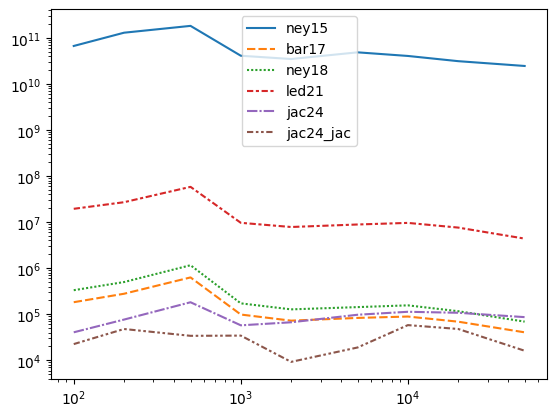

In [5]:
# plot6 = sns.lineplot(data = df_cifar_comp, legend = True, ax=ax[0])
# plot6.set(xscale="log", yscale="log")

df = pd.read_pickle('comp_df_vg8.0_vh8.0.pkl').iloc[-9:]
df.index = [100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000]
plot6 = sns.lineplot(data = df)
plot6.set(xscale="log", yscale="log")

[None, None]

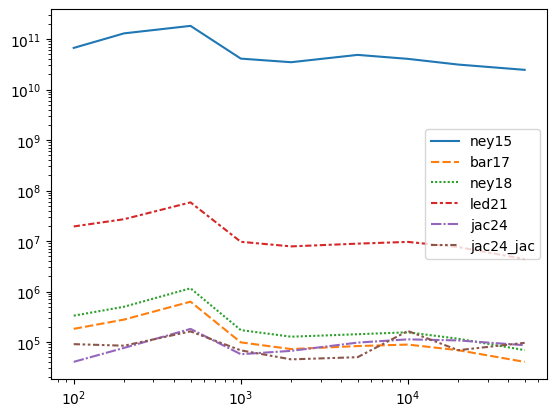

In [8]:
df = pd.read_pickle('comp_df_vg8.0_vh2.0.pkl').iloc[-9:]
df.index = [100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000]
plot6 = sns.lineplot(data = df)
plot6.set(xscale="log", yscale="log")

[None, None]

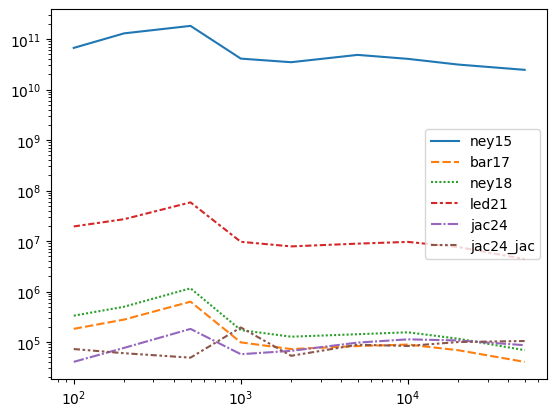

In [9]:
df = pd.read_pickle('comp_df_vg2.0_vh8.0.pkl').iloc[-9:]
df.index = [100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000]
plot6 = sns.lineplot(data = df)
plot6.set(xscale="log", yscale="log")

[None, None]

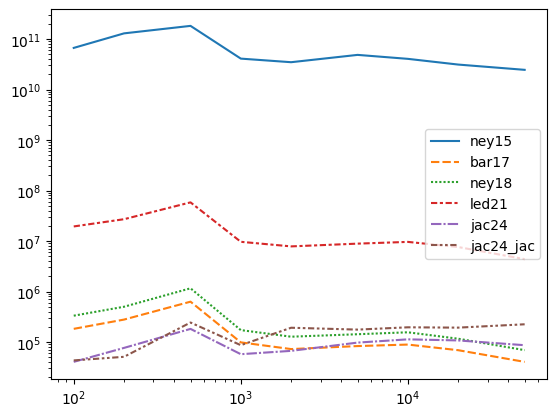

In [10]:
df = pd.read_pickle('comp_df_vg2.0_vh2.0.pkl').iloc[-9:]
df.index = [100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000]
plot6 = sns.lineplot(data = df)
plot6.set(xscale="log", yscale="log")

In [8]:
comp_list

[tensor(43488.7148, device='cuda:0', grad_fn=<DivBackward0>),
 tensor(89922.4453, device='cuda:0', grad_fn=<DivBackward0>),
 tensor(98354.4688, device='cuda:0', grad_fn=<DivBackward0>),
 tensor(125736.1250, device='cuda:0', grad_fn=<DivBackward0>),
 tensor(112726.1641, device='cuda:0', grad_fn=<DivBackward0>),
 tensor(92138.3984, device='cuda:0', grad_fn=<DivBackward0>)]

In [29]:
lip_list

[[tensor(0.9910, device='cuda:0', grad_fn=<MulBackward0>),
  tensor(1.0509, device='cuda:0', grad_fn=<MulBackward0>),
  tensor(1.9319, device='cuda:0', grad_fn=<MulBackward0>),
  tensor(1.8772, device='cuda:0', grad_fn=<MulBackward0>),
  tensor(1.8857, device='cuda:0', grad_fn=<MulBackward0>),
  tensor(1.9873, device='cuda:0', grad_fn=<MulBackward0>),
  tensor(1.6410, device='cuda:0', grad_fn=<MulBackward0>)],
 [tensor(0.9680, device='cuda:0', grad_fn=<MulBackward0>),
  tensor(0.8975, device='cuda:0', grad_fn=<MulBackward0>),
  tensor(1.9472, device='cuda:0', grad_fn=<MulBackward0>),
  tensor(1.9452, device='cuda:0', grad_fn=<MulBackward0>),
  tensor(1.9677, device='cuda:0', grad_fn=<MulBackward0>),
  tensor(2.0592, device='cuda:0', grad_fn=<MulBackward0>),
  tensor(1.6377, device='cuda:0', grad_fn=<MulBackward0>)],
 [tensor(0.9470, device='cuda:0', grad_fn=<MulBackward0>),
  tensor(0.8942, device='cuda:0', grad_fn=<MulBackward0>),
  tensor(1.9979, device='cuda:0', grad_fn=<MulBackward

In [12]:
comp_list

[tensor(122438.6484, device='cuda:0', grad_fn=<DivBackward0>),
 tensor(116675.5625, device='cuda:0', grad_fn=<DivBackward0>),
 tensor(91063.1953, device='cuda:0', grad_fn=<DivBackward0>)]

In [ ]:
N = [100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000]
comp_dict = {}
ney15 = []
bar17 = []
ney18 = []
led21 = []
jac24 = []
jac24_jac = []

for vg in [9.0, 10.0]:
    for vh in [9.0, 10.0]:
        
        ney15 = []
        bar17 = []
        ney18 = []
        led21 = []
        jac24 = []
        jac24_jac = []
        
        for n in tqdm(N):
            net = Net(widths = [15] + [500]*12 + [20], loss='L2', test_loss='L2', prof=False, AccNets = False, jac = False).cuda()
            net.load_state_dict(torch.load('model_weights/Weight_dnn_N{n}_vg8.0_vh8.0_L2L2_torch_w500_500_w8decay_5_dnn_L4_3.pth'.format(n=n)))
            ney15.append(net.Neyshabur15(X[:n], n).item())
            bar17.append(net.Bartlett17(X[:n], n).item())
            ney18.append(net.Neyshabur18(X[:n], n).item())
            led21.append(net.Ledent21(X[:n], n).item())
            jac24.append(net.complexities(X[:n]).item())
            
            net = Net(widths = [15] + [500]*12 + [20], loss='L2', test_loss='L2', prof=False, AccNets = False, jac = True).cuda()
            net.load_state_dict(torch.load('model_weights/Weight_dnn_N{n}_vg{vg}_vh{vh}_L2L2_torch_w500_500_w8decay_5_dnn_L4_3.pth'.format(n=n, vg=vg, vh=vh)))
            jac24_jac.append(net.complexities(X[:n]).item())
            
        comp_dict = {'ney15' : ney15, 'bar17': bar17, 'ney18' : ney18, 'led21' : led21, 'jac24' : jac24, 'jac24_jac' : jac24_jac}
        pd.DataFrame(comp_dict).to_pickle('comp_df_vg{vg}_vh{vh}_2.pkl'.format(vg=vg, vh=vh))
            
    # comp_list.append(net.complexities(X[:n]).item())


  0%|          | 0/9 [00:00<?, ?it/s]/scratch/shc443/thesis/AccNets4.py:174: UserWarning: torch.linalg.svd: During SVD computation with the selected cusolver driver, batches 0 failed to converge. A more accurate method will be used to compute the SVD as a fallback. Check doc at https://pytorch.org/docs/stable/generated/torch.linalg.svd.html (Triggered internally at ../aten/src/ATen/native/cuda/linalg/BatchLinearAlgebraLib.cpp:697.)
  Lip_op = [torch.linalg.matrix_norm(linear.weight, ord=2).item() for linear in self.linears]
 11%|█         | 1/9 [01:27<11:40, 87.52s/it]

In [23]:
comp_dict = {'ney15' : ney15, 'bar17': bar17, 'ney18' : ney18, 'led21' : led21, 'jac24' : jac24}
pd.DataFrame(comp_dict)

,ney15,bar17,ney18,led21,jac24
0,4.103217e+10,98610.562500,172486.500000,9668352.0,25018.542969
1,3.483668e+10,72638.437500,127679.812500,7844639.5,44594.636719
2,4.863650e+10,83307.031250,142957.796875,8893823.0,65738.609375
3,4.059240e+10,89209.687500,156120.875000,9632751.0,24557.441406
4,3.128175e+10,69010.953125,116468.562500,7619386.0,33142.093750
5,2.459645e+10,40512.031250,69196.257812,4387700.5,34660.855469


In [14]:
ney18

[172486.5, 127679.8125, 142957.796875, 156120.875, 116468.5625, 69196.2578125]

In [17]:
jac24

[25018.54296875,
 44594.63671875,
 65738.609375,
 24557.44140625,
 33142.09375,
 34660.85546875]

In [14]:
[(torch.linalg.matrix_norm(net.linears[0].weight, ord=2) * torch.linalg.matrix_norm(net.linears[1].weight, ord=2) ** 0.5)]

[tensor(1.0757, device='cuda:0', grad_fn=<MulBackward0>)]

In [16]:
N = [10000, 20000, 50000]
comp_list = []
for n in tqdm(N):
    net = Net(widths = [15] + [500]*12 + [20], loss='L2', test_loss='L2', prof=False, AccNets = False, jac = True).cuda()
    net.load_state_dict(torch.load('model_weights/Weight_dnn_N{n}_vg8.5_vh8.0_L2L2_torch_w500_500_w8decay_5_dnn_L4_3.pth'.format(n=n)))
    lip_ops = net.Lip_OP()
    # comp_list.append(net.complexities(X[:n]))
    break


  0%|          | 0/3 [00:16<?, ?it/s]

KeyboardInterrupt



In [17]:
trials = 100
grad_ops = torch.zeros([len(range(2, len(net.linears)-1, 2)), trials])

for idx, layer in enumerate(range(2, len(net.linears)-1, 2)): 
        
    temp_weight_in = net.linears[layer-1]
    temp_weight_out = net.linears[layer]
    
    with torch.no_grad():
        temp_weight_in.weight = torch.nn.Parameter(net.sqrt_weight(net.linears[layer-1]))
        temp_weight_out.weight = torch.nn.Parameter(net.sqrt_weight(net.linears[layer]))
        
    def shallow(z):
        return temp_weight_out(net.nonlin(temp_weight_in(z)))
        
        #self.out_linears[layer](self.nonlin(self.in_linears[layer](z)))
       
    for i in range(trials):
        J = torch.autograd.functional.jacobian(shallow, torch.randn([temp_weight_in.in_features])
                                           .cuda()).reshape([temp_weight_in.in_features, temp_weight_out.out_features])
        
    grad_ops[idx, i] = torch.linalg.matrix_norm(J,ord=2).item()
    
Lip_ops = grad_ops.max(axis=1) #middle

In [27]:
[(torch.linalg.matrix_norm(net.linears[0].weight, ord=2) * torch.linalg.matrix_norm(net.linears[1].weight, ord=2) ** 0.5).item()] + Lip_ops.values.tolist() +  [(torch.linalg.matrix_norm(net.linears[0].weight, ord=2) * torch.linalg.matrix_norm(net.linears[1].weight, ord=2) ** 0.5).item()]


[1.120701789855957,
 0.6755838990211487,
 0.9696479439735413,
 1.213570475578308,
 1.5159059762954712,
 1.1553938388824463,
 1.120701789855957]

In [ ]:
net = Net(widths = [15] + [500]*12 + [20], loss='L2', test_loss='L2', prof=False, AccNets = False, jac = False).cuda()
net.load_state_dict(torch.load('model_weights/Weight_dnn_N500_vg1.5_vh5.0_L2L2_torch_w500_500_w8decay_5_dnn_L4_3.pth'))
net.complexities(X[:500])

In [ ]:
for idx in range(2, len(net.linears)-1, 2):
    print(idx)

In [10]:
def sqrt_weight(W):
    """Compute the square root of the weight matrices s.t. the matrix Usqrt(S)V^T if USV^T is the SVD decomposition"""        
    U, S, Vh = torch.svd(W.weight)
    return torch.mm(torch.mm(U, torch.diag(torch.sqrt(S))), Vh.t())

In [61]:
sqrt_weight(net.linears[0])

tensor([[-0.0797,  0.0512,  0.0080,  ..., -0.0628, -0.0515,  0.0841],
        [ 0.0740, -0.0379,  0.0243,  ..., -0.0294, -0.0285, -0.0669],
        [-0.0025,  0.0117,  0.0719,  ...,  0.0680, -0.1181,  0.0915],
        ...,
        [ 0.0781,  0.0516, -0.0162,  ..., -0.0005, -0.0502, -0.0546],
        [-0.0167, -0.0255,  0.0691,  ...,  0.0432, -0.0453,  0.0277],
        [-0.0622, -0.0368,  0.0060,  ..., -0.0191,  0.0026, -0.0106]],
       device='cuda:0', grad_fn=<MmBackward0>)

In [40]:
net.linears[0].weight

Parameter containing:
tensor([[-0.0878,  0.0571,  0.0108,  ..., -0.0679, -0.0557,  0.0906],
        [ 0.0809, -0.0410,  0.0228,  ..., -0.0321, -0.0306, -0.0720],
        [-0.0066,  0.0122,  0.0778,  ...,  0.0757, -0.1268,  0.1008],
        ...,
        [ 0.0854,  0.0550, -0.0207,  ...,  0.0008, -0.0527, -0.0592],
        [-0.0178, -0.0277,  0.0735,  ...,  0.0471, -0.0499,  0.0335],
        [-0.0679, -0.0396,  0.0066,  ..., -0.0212,  0.0034, -0.0116]],
       device='cuda:0', requires_grad=True)

In [31]:
(torch.diag(S)@Vh).shape

torch.Size([15, 15])

In [7]:
trials = 100
grad_ops = np.zeros([len(range(2, len(net.linears)-1, 2)), trials])

for idx, layer in enumerate(range(2, len(net.linears)-1, 2)): 
    def shallow(z):
        return net.linears[layer](net.nonlin(net.linears[layer-1](z)))
        
        #self.out_linears[layer](self.nonlin(self.in_linears[layer](z)))
       
    for i in range(trials):
        J = torch.autograd.functional.jacobian(shallow, torch.randn([net.linears[layer].in_features])
                                           .cuda()).reshape([net.linears[layer].in_features, net.linears[layer].out_features])
    grad_ops[idx, i] = torch.linalg.matrix_norm(J,ord=2).item()
            
Lip_ops = grad_ops.max(axis=1)

In [8]:
Lip_ops

array([0.85961169, 0.98151445, 1.68465674, 1.69773793, 1.76554883])

In [64]:
trials = 100
grad_ops = np.zeros([len(range(2, len(net.linears)-1, 2)), trials])

for idx, layer in enumerate(range(2, len(net.linears)-1, 2)): 
    def shallow(z):
        return sqrt_weight(net.linears[layer])(net.nonlin(sqrt_weight(net.linears[layer-1])(z)))
        
        #self.out_linears[layer](self.nonlin(self.in_linears[layer](z)))
       
    for i in range(trials):
        J = torch.autograd.functional.jacobian(shallow, torch.randn([net.linears[layer].in_features])
                                           .cuda()).reshape([net.linears[layer].in_features, net.linears[layer].out_features])
    grad_ops[idx, i] = torch.linalg.matrix_norm(J,ord=2).item()
            
Lip_ops = grad_ops.max(axis=1)

TypeError: 'Tensor' object is not callable

In [161]:
net = Net(widths = [15] + [500]*12 + [20], loss='L2', test_loss='L2', prof=False, AccNets = False, jac = False).cuda()
net.load_state_dict(torch.load('model_weights/Weight_dnn_N500_vg1.5_vh5.0_L2L2_torch_w500_500_w8decay_5_dnn_L4_3.pth'))
net.linears[0](X)

tensor([[ 0.0182,  0.0678, -0.0458,  ..., -0.0142, -0.3002,  0.0483],
        [-0.0637, -0.3151,  0.3493,  ..., -0.0226,  0.2207,  0.0201],
        [ 0.0616,  0.0235, -0.3307,  ..., -0.1331, -0.1431, -0.0211],
        ...,
        [ 0.2954,  0.2614, -0.0827,  ..., -0.1183,  0.1870,  0.1395],
        [-0.0451, -0.1101,  0.1296,  ..., -0.0123,  0.0009, -0.0091],
        [-0.2164, -0.2095, -0.0573,  ..., -0.1119, -0.0418,  0.0913]],
       device='cuda:0', grad_fn=<AddmmBackward0>)

In [143]:
with torch.no_grad():
    net.linears[0].weight = torch.nn.Parameter(sqrt_weight(net.linears[0]))

In [154]:
temp_weight = net.linears[0]

In [11]:
trials = 100
grad_ops = np.zeros([len(range(2, len(net.linears)-1, 2)), trials])

temp_weight_in = net.linears[layer-1]
temp_weight_out = net.linears[layer]

with torch.no_grad():
    temp_weight_in.weight = torch.nn.Parameter(sqrt_weight(net.linears[layer-1]))
    temp_weight_out.weight = torch.nn.Parameter(sqrt_weight(net.linears[layer]))
    
for idx, layer in enumerate(range(2, len(net.linears)-1, 2)): 
    def shallow(z):
        return temp_weight_out(net.nonlin(temp_weight_in(z)))
        
        #self.out_linears[layer](self.nonlin(self.in_linears[layer](z)))
       
    for i in range(trials):
        J = torch.autograd.functional.jacobian(shallow, torch.randn([temp_weight_in.in_features])
                                           .cuda()).reshape([temp_weight_in.in_features, temp_weight_out.out_features])
    grad_ops[idx, i] = torch.linalg.matrix_norm(J,ord=2).item()
            
Lip_ops = grad_ops.max(axis=1)

In [ ]:
Lip_ops

In [164]:
net.Lip_OP()

[tensor(1.3387, device='cuda:0', grad_fn=<MulBackward0>),
 tensor(1.3467, device='cuda:0', grad_fn=<MulBackward0>),
 tensor(1.9623, device='cuda:0', grad_fn=<MulBackward0>),
 tensor(1.9912, device='cuda:0', grad_fn=<MulBackward0>),
 tensor(2.0152, device='cuda:0', grad_fn=<MulBackward0>),
 tensor(2.2029, device='cuda:0', grad_fn=<MulBackward0>),
 tensor(1.5953, device='cuda:0', grad_fn=<MulBackward0>)]

In [157]:
net2.linears[0].weight

Parameter containing:
tensor([[-0.0760,  0.0486,  0.0067,  ..., -0.0604, -0.0497,  0.0810],
        [ 0.0708, -0.0365,  0.0250,  ..., -0.0281, -0.0274, -0.0646],
        [-0.0007,  0.0115,  0.0693,  ...,  0.0644, -0.1141,  0.0872],
        ...,
        [ 0.0747,  0.0500, -0.0142,  ..., -0.0011, -0.0490, -0.0525],
        [-0.0161, -0.0244,  0.0670,  ...,  0.0415, -0.0432,  0.0250],
        [-0.0595, -0.0354,  0.0057,  ..., -0.0181,  0.0023, -0.0102]],
       device='cuda:0', requires_grad=True)

In [21]:
net.linears[0]#(X)

TypeError: sqrt(): argument 'input' (position 1) must be Tensor, not Linear

In [ ]:
torch.sqrt(net.nonlin(net.linears[0](X)))